In [2]:
pip install mp-api pymatgen pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

df = pd.read_csv("../data/processed/Si_ML_ready_clean.csv")

print(df.columns)
print(len(df))

Index(['Synthesizable', 'Material ID', 'Formula', 'Crystal System',
       'Space Group Symbol', 'Space Group Number', 'Sites',
       'Energy Above Hull', 'Formation Energy', 'Predicted Stable', 'Volume',
       'Density', 'Band Gap', 'Is Gap Direct', 'Is Metal', 'Magnetic Ordering',
       'Total Magnetization', 'Bulk Modulus, Voigt', 'Bulk Modulus, Reuss',
       'Bulk Modulus, VRH', 'Shear Modulus, Voigt', 'Shear Modulus, Reuss',
       'Shear Modulus, VRH', 'Elastic Anisotropy', 'Weighted Surface Energy',
       'Surface Anisotropy', 'Shape Factor', 'Work Function',
       'Piezoelectric Modulus', 'Total Dielectric Constant',
       'Ionic Dielectric Constant', 'Static Dielectric Constant', 'Si_frac',
       'O_frac', 'C_frac', 'N_frac'],
      dtype='object')
438


In [4]:
import pandas as pd

# load your cleaned dataset
df = pd.read_csv("../data/processed/Si_ML_ready_clean.csv")

# filter SiO2 using atomic fractions
df_sio2 = df[
    (abs(df["Si_frac"] - 1/3) < 0.001) &
    (abs(df["O_frac"] - 2/3) < 0.001)
]

# show how many materials
print("Number of SiO2 materials:", len(df_sio2))

# optional: look at the first few rows
df_sio2.head()

Number of SiO2 materials: 321


,Synthesizable,Material ID,Formula,Crystal System,Space Group Symbol,Space Group Number,Sites,Energy Above Hull,Formation Energy,Predicted Stable,...,Shape Factor,Work Function,Piezoelectric Modulus,Total Dielectric Constant,Ionic Dielectric Constant,Static Dielectric Constant,Si_frac,O_frac,C_frac,N_frac
62,True,mp-10064,SiO2,Cubic,Fm-3m,225,3,1.277944,-1.994888,False,...,NaN,NaN,NaN,NaN,NaN,NaN,0.333333,0.666667,0.0,0.0
63,True,mp-1021503,SiO2,Cubic,Pn-3m,224,6,0.397136,-2.875695,False,...,NaN,NaN,NaN,NaN,NaN,NaN,0.333333,0.666667,0.0,0.0
64,False,mp-1071820,SiO2,Orthorhombic,Ibam,72,6,0.442452,-2.830380,False,...,NaN,NaN,NaN,NaN,NaN,NaN,0.333333,0.666667,0.0,0.0
65,False,mp-10851,SiO2,Hexagonal,P6_422,181,9,0.009073,-3.263758,False,...,NaN,NaN,0.153285,4.521754,2.16945,2.352304,0.333333,0.666667,0.0,0.0
66,False,mp-10948,SiO2,Orthorhombic,Pbcn,60,12,0.259839,-3.012992,False,...,NaN,NaN,NaN,NaN,NaN,NaN,0.333333,0.666667,0.0,0.0


In [5]:
# keep only the material IDs
df_ids = df_sio2[["Material ID"]].drop_duplicates()

print("Unique material IDs:", len(df_ids))
display(df_ids.head())

# save for the API step
df_ids.to_csv("../data/processed/SiO2_material_ids.csv", index=False)

Unique material IDs: 321


,Material ID
62,mp-10064
63,mp-1021503
64,mp-1071820
65,mp-10851
66,mp-10948


DATA ACQUISITION

In [6]:
from mp_api.client import MPRester
import pandas as pd

API_KEY = "lFHsBvSH3VD2ETcdiID1R435rj4VgPAg"

df_ids = pd.read_csv("../data/processed/SiO2_material_ids.csv")
material_ids = df_ids["Material ID"].astype(str).tolist()

with MPRester(API_KEY) as mpr:
    docs = mpr.materials.summary.search(
        material_ids=material_ids,
        fields=["material_id", "band_gap", "structure"]
    )

print("Structures returned:", len(docs))

Retrieving SummaryDoc documents:   0%|          | 0/321 [00:00<?, ?it/s]

Structures returned: 321


In [7]:
rows = []

for doc in docs:
    rows.append({
        "material_id": str(doc.material_id),
        "band_gap": doc.band_gap,
        "structure": doc.structure.as_dict()
    })

df_structures = pd.DataFrame(rows)

print("Rows in structure dataframe:", len(df_structures))
display(df_structures.head())

df_structures.to_json("../data/raw/SiO2_structures.json", orient="records")

Rows in structure dataframe: 321


,material_id,band_gap,structure
0,mp-558733,5.2900,"{'@module': 'pymatgen.core.structure', '@class..."
1,mp-558891,5.6471,"{'@module': 'pymatgen.core.structure', '@class..."
2,mp-558931,4.6434,"{'@module': 'pymatgen.core.structure', '@class..."
3,mp-558947,5.7972,"{'@module': 'pymatgen.core.structure', '@class..."
4,mp-559091,5.4377,"{'@module': 'pymatgen.core.structure', '@class..."


In [8]:
from pymatgen.core import Structure

# take the first saved structure
sample_structure_dict = df_structures.loc[0, "structure"]

# convert dict back to pymatgen Structure object
sample_structure = Structure.from_dict(sample_structure_dict)

print(sample_structure)
print("Number of sites:", len(sample_structure))

Full Formula (Si6 O12)
Reduced Formula: SiO2
abc   :   6.854984   6.854984   4.643195
angles:  79.677722  79.677722  43.305016
pbc   :       True       True       True
Sites (18)
  #  SP           a         b         c    magmom
---  ----  --------  --------  --------  --------
  0  Si    0.691722  0.981197  0.329688         0
  1  Si    0.308278  0.018803  0.670312         0
  2  Si    0.357809  0.642191  0.25             0
  3  Si    0.981197  0.691722  0.829688         0
  4  Si    0.642191  0.357809  0.75             0
  5  Si    0.018803  0.308278  0.170312         0
  6  O     0.963251  0.218748  0.539576        -0
  7  O     0.302411  0.548571  0.961232         0
  8  O     0.218748  0.963251  0.039576        -0
  9  O     0.697589  0.451429  0.038768         0
 10  O     0.860259  0.656572  0.180659        -0
 11  O     0.343428  0.139741  0.319341        -0
 12  O     0.139741  0.343428  0.819341        -0
 13  O     0.036749  0.781252  0.460424        -0
 14  O     0.656572  

FEATURE ENGINEERING 

In [9]:
import numpy as np

def avg_si_o_distance(structure, cutoff=2.2):
    distances = []

    for site in structure:
        if site.specie.symbol == "Si":
            neighbors = structure.get_neighbors(site, cutoff)

            for nn in neighbors:
                if nn.specie.symbol == "O":
                    distances.append(nn.nn_distance)

    if len(distances) == 0:
        return np.nan

    return np.mean(distances)

print("Average Si-O distance:", avg_si_o_distance(sample_structure))

Average Si-O distance: 1.796240796186126


In [10]:
from pymatgen.core import Structure

si_o_avg_list = []

for s in df_structures["structure"]:

    struct = Structure.from_dict(s)

    si_o_avg_list.append(avg_si_o_distance(struct))

df_structures["avg_si_o_distance"] = si_o_avg_list

print(df_structures[["material_id", "band_gap", "avg_si_o_distance"]].head())

  material_id  band_gap  avg_si_o_distance
0   mp-558733    5.2900           1.796241
1   mp-558891    5.6471           1.610288
2   mp-558931    4.6434           1.643527
3   mp-558947    5.7972           1.623726
4   mp-559091    5.4377           1.607429


In [11]:
import numpy as np
from pymatgen.core import Structure

def avg_si_o_si_angle(structure, cutoff=2.2):

    angles = []

    for site in structure:

        if site.specie.symbol == "O":

            neighbors = structure.get_neighbors(site, cutoff)

            si_neighbors = [n for n in neighbors if n.specie.symbol == "Si"]

            if len(si_neighbors) >= 2:

                for i in range(len(si_neighbors)):
                    for j in range(i+1, len(si_neighbors)):

                        v1 = si_neighbors[i].coords - site.coords
                        v2 = si_neighbors[j].coords - site.coords

                        cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

                        angle = np.degrees(np.arccos(np.clip(cos_angle, -1, 1)))

                        angles.append(angle)

    if len(angles) == 0:
        return np.nan

    return np.mean(angles)

In [12]:
angle_value = avg_si_o_si_angle(sample_structure)
print("Average Si-O-Si angle:", angle_value)

Average Si-O-Si angle: 119.33893165534212


In [13]:
angles = []

for s in df_structures["structure"]:
    
    struct = Structure.from_dict(s)
    
    angles.append(avg_si_o_si_angle(struct))

df_structures["avg_si_o_si_angle"] = angles

df_structures[
    ["material_id","band_gap","avg_si_o_distance","avg_si_o_si_angle"]
].head()

,material_id,band_gap,avg_si_o_distance,avg_si_o_si_angle
0,mp-558733,5.2900,1.796241,119.338932
1,mp-558891,5.6471,1.610288,148.798537
2,mp-558931,4.6434,1.643527,139.111042
3,mp-558947,5.7972,1.623726,150.914335
4,mp-559091,5.4377,1.607429,158.460309


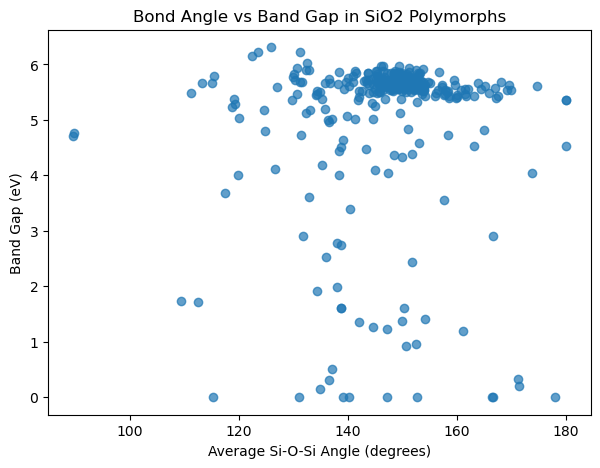

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(
    df_structures["avg_si_o_si_angle"],
    df_structures["band_gap"],
    alpha=0.7
)

plt.xlabel("Average Si-O-Si Angle (degrees)")
plt.ylabel("Band Gap (eV)")
plt.title("Bond Angle vs Band Gap in SiO2 Polymorphs")

plt.show()

In [15]:
df_structures.sort_values("band_gap").head(10)

,material_id,band_gap,structure,avg_si_o_distance,avg_si_o_si_angle
263,mp-638038,0.0000,"{'@module': 'pymatgen.core.structure', '@class...",1.714752,166.518005
264,mp-638049,0.0000,"{'@module': 'pymatgen.core.structure', '@class...",1.784890,131.083457
99,mp-556044,0.0000,"{'@module': 'pymatgen.core.structure', '@class...",1.634484,147.125481
303,mp-685184,0.0000,"{'@module': 'pymatgen.core.structure', '@class...",1.623542,152.721371
204,mp-1398433,0.0000,"{'@module': 'pymatgen.core.structure', '@class...",1.557701,139.035839
132,mp-557194,0.0000,"{'@module': 'pymatgen.core.structure', '@class...",1.720908,177.984454
262,mp-638035,0.0000,"{'@module': 'pymatgen.core.structure', '@class...",1.764736,166.636939
84,mp-555394,0.0000,"{'@module': 'pymatgen.core.structure', '@class...",1.651571,115.188383
159,mp-558598,0.0000,"{'@module': 'pymatgen.core.structure', '@class...",1.760503,140.227784
168,mp-1179488,0.1419,"{'@module': 'pymatgen.core.structure', '@class...",1.671147,134.924706


In [16]:
df_structures.sort_values("avg_si_o_si_angle").head(10)

,material_id,band_gap,structure,avg_si_o_distance,avg_si_o_si_angle
162,mp-1071820,4.7160,"{'@module': 'pymatgen.core.structure', '@class...",1.672388,89.567793
313,mp-7905,4.7647,"{'@module': 'pymatgen.core.structure', '@class...",1.674659,89.821141
160,mp-10064,1.7396,"{'@module': 'pymatgen.core.structure', '@class...",1.984424,109.471221
97,mp-555960,5.4799,"{'@module': 'pymatgen.core.structure', '@class...",1.656590,111.301283
301,mp-683953,1.7254,"{'@module': 'pymatgen.core.structure', '@class...",1.701461,112.458612
152,mp-558301,5.6614,"{'@module': 'pymatgen.core.structure', '@class...",1.654505,113.243350
5,mp-559273,5.6600,"{'@module': 'pymatgen.core.structure', '@class...",1.651684,115.067290
84,mp-555394,0.0000,"{'@module': 'pymatgen.core.structure', '@class...",1.651571,115.188383
203,mp-1365799,5.7930,"{'@module': 'pymatgen.core.structure', '@class...",1.648418,115.433944
104,mp-556257,3.6775,"{'@module': 'pymatgen.core.structure', '@class...",1.664567,117.522185


EDA

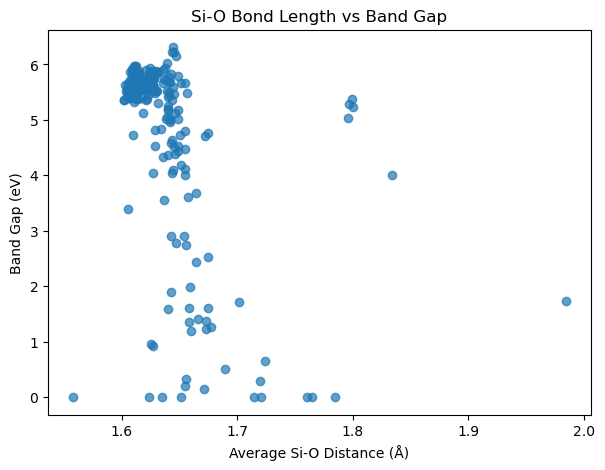

In [17]:
plt.figure(figsize=(7,5))

plt.scatter(
    df_structures["avg_si_o_distance"],
    df_structures["band_gap"],
    alpha=0.7
)

plt.xlabel("Average Si-O Distance (Å)")
plt.ylabel("Band Gap (eV)")
plt.title("Si-O Bond Length vs Band Gap")

plt.show()

In [18]:
def si_o_si_angle_stats(structure, cutoff=2.2):

    angles = []

    for site in structure:

        if site.specie.symbol == "O":

            neighbors = structure.get_neighbors(site, cutoff)

            si_neighbors = [n for n in neighbors if n.specie.symbol == "Si"]

            if len(si_neighbors) >= 2:

                for i in range(len(si_neighbors)):
                    for j in range(i+1, len(si_neighbors)):

                        v1 = si_neighbors[i].coords - site.coords
                        v2 = si_neighbors[j].coords - site.coords

                        cos_angle = np.dot(v1, v2) / (
                            np.linalg.norm(v1) * np.linalg.norm(v2)
                        )

                        angle = np.degrees(np.arccos(np.clip(cos_angle, -1, 1)))

                        angles.append(angle)

    if len(angles) == 0:
        return np.nan, np.nan, np.nan

    return np.min(angles), np.max(angles), np.std(angles)

In [19]:
min_angles = []
max_angles = []
std_angles = []

for s in df_structures["structure"]:

    struct = Structure.from_dict(s)

    mn, mx, std = si_o_si_angle_stats(struct)

    min_angles.append(mn)
    max_angles.append(mx)
    std_angles.append(std)

df_structures["min_si_o_si_angle"] = min_angles
df_structures["max_si_o_si_angle"] = max_angles
df_structures["std_si_o_si_angle"] = std_angles

In [20]:
df_structures[
    [
        "material_id",
        "band_gap",
        "avg_si_o_distance",
        "avg_si_o_si_angle",
        "min_si_o_si_angle",
        "max_si_o_si_angle",
        "std_si_o_si_angle"
    ]
].head()

,material_id,band_gap,avg_si_o_distance,avg_si_o_si_angle,min_si_o_si_angle,max_si_o_si_angle,std_si_o_si_angle
0,mp-558733,5.2900,1.796241,119.338932,98.443161,159.493705,20.183651
1,mp-558891,5.6471,1.610288,148.798537,148.798288,148.798784,0.000246
2,mp-558931,4.6434,1.643527,139.111042,133.640176,148.421086,5.567246
3,mp-558947,5.7972,1.623726,150.914335,145.175210,159.964207,4.897316
4,mp-559091,5.4377,1.607429,158.460309,151.280378,180.000000,12.435947


In [21]:
df_structures.sort_values("band_gap").head(10)

,material_id,band_gap,structure,avg_si_o_distance,avg_si_o_si_angle,min_si_o_si_angle,max_si_o_si_angle,std_si_o_si_angle
263,mp-638038,0.0000,"{'@module': 'pymatgen.core.structure', '@class...",1.714752,166.518005,153.036011,180.000000,13.481995
264,mp-638049,0.0000,"{'@module': 'pymatgen.core.structure', '@class...",1.784890,131.083457,104.953777,157.213137,26.129680
99,mp-556044,0.0000,"{'@module': 'pymatgen.core.structure', '@class...",1.634484,147.125481,124.312636,180.000000,23.821539
303,mp-685184,0.0000,"{'@module': 'pymatgen.core.structure', '@class...",1.623542,152.721371,134.257795,169.830902,5.817680
204,mp-1398433,0.0000,"{'@module': 'pymatgen.core.structure', '@class...",1.557701,139.035839,107.008385,151.599743,18.600601
132,mp-557194,0.0000,"{'@module': 'pymatgen.core.structure', '@class...",1.720908,177.984454,175.968557,180.000000,2.015546
262,mp-638035,0.0000,"{'@module': 'pymatgen.core.structure', '@class...",1.764736,166.636939,153.273876,180.000000,13.363061
84,mp-555394,0.0000,"{'@module': 'pymatgen.core.structure', '@class...",1.651571,115.188383,88.995326,127.135168,15.560221
159,mp-558598,0.0000,"{'@module': 'pymatgen.core.structure', '@class...",1.760503,140.227784,127.054488,153.401124,13.173161
168,mp-1179488,0.1419,"{'@module': 'pymatgen.core.structure', '@class...",1.671147,134.924706,89.918256,168.676043,19.486259


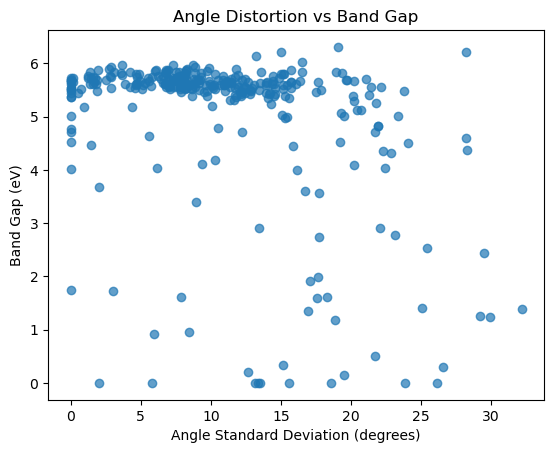

In [22]:
plt.scatter(
    df_structures["std_si_o_si_angle"],
    df_structures["band_gap"],
    alpha=0.7
)

plt.xlabel("Angle Standard Deviation (degrees)")
plt.ylabel("Band Gap (eV)")
plt.title("Angle Distortion vs Band Gap")

plt.show()

In [23]:
df_structures["is_metal"] = df_structures["band_gap"] < 0.2

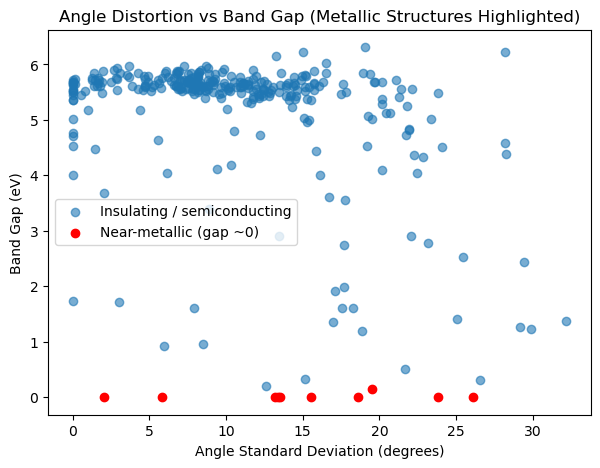

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

# normal structures
normal = df_structures[~df_structures["is_metal"]]
plt.scatter(
    normal["std_si_o_si_angle"],
    normal["band_gap"],
    alpha=0.6,
    label="Insulating / semiconducting"
)

# metallic structures
metals = df_structures[df_structures["is_metal"]]
plt.scatter(
    metals["std_si_o_si_angle"],
    metals["band_gap"],
    color="red",
    label="Near-metallic (gap ~0)"
)

plt.xlabel("Angle Standard Deviation (degrees)")
plt.ylabel("Band Gap (eV)")
plt.title("Angle Distortion vs Band Gap (Metallic Structures Highlighted)")
plt.legend()
plt.show()

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

features = df_structures[
    [
        "avg_si_o_distance",
        "avg_si_o_si_angle",
        "min_si_o_si_angle",
        "max_si_o_si_angle",
        "std_si_o_si_angle"
    ]
]

target = df_structures["band_gap"]

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

importances = pd.Series(
    model.feature_importances_,
    index=features.columns
)

print(importances.sort_values(ascending=False))

avg_si_o_distance    0.645760
avg_si_o_si_angle    0.157771
min_si_o_si_angle    0.105745
std_si_o_si_angle    0.054971
max_si_o_si_angle    0.035752
dtype: float64


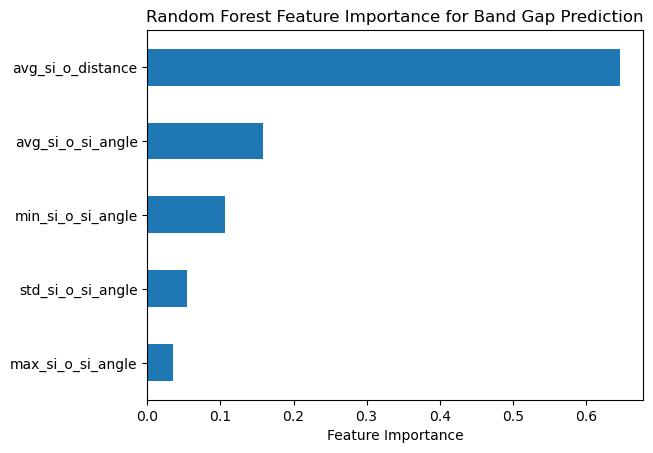

In [26]:
import matplotlib.pyplot as plt

importances.sort_values().plot(kind="barh")

plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance for Band Gap Prediction")

plt.show()

ML RESULTS

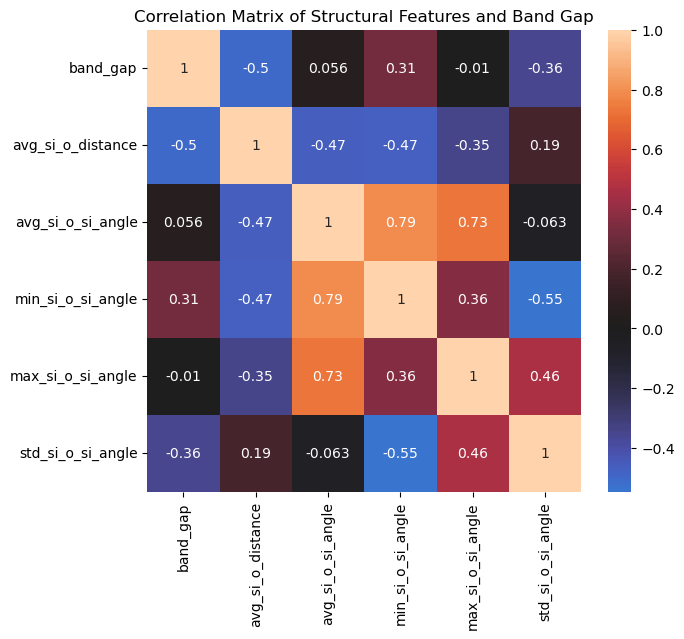

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

features = df_structures[
    [
        "band_gap",
        "avg_si_o_distance",
        "avg_si_o_si_angle",
        "min_si_o_si_angle",
        "max_si_o_si_angle",
        "std_si_o_si_angle"
    ]
]

corr = features.corr()

plt.figure(figsize=(7,6))

sns.heatmap(
    corr,
    annot=True,
    center=0
)

plt.title("Correlation Matrix of Structural Features and Band Gap")

plt.show()

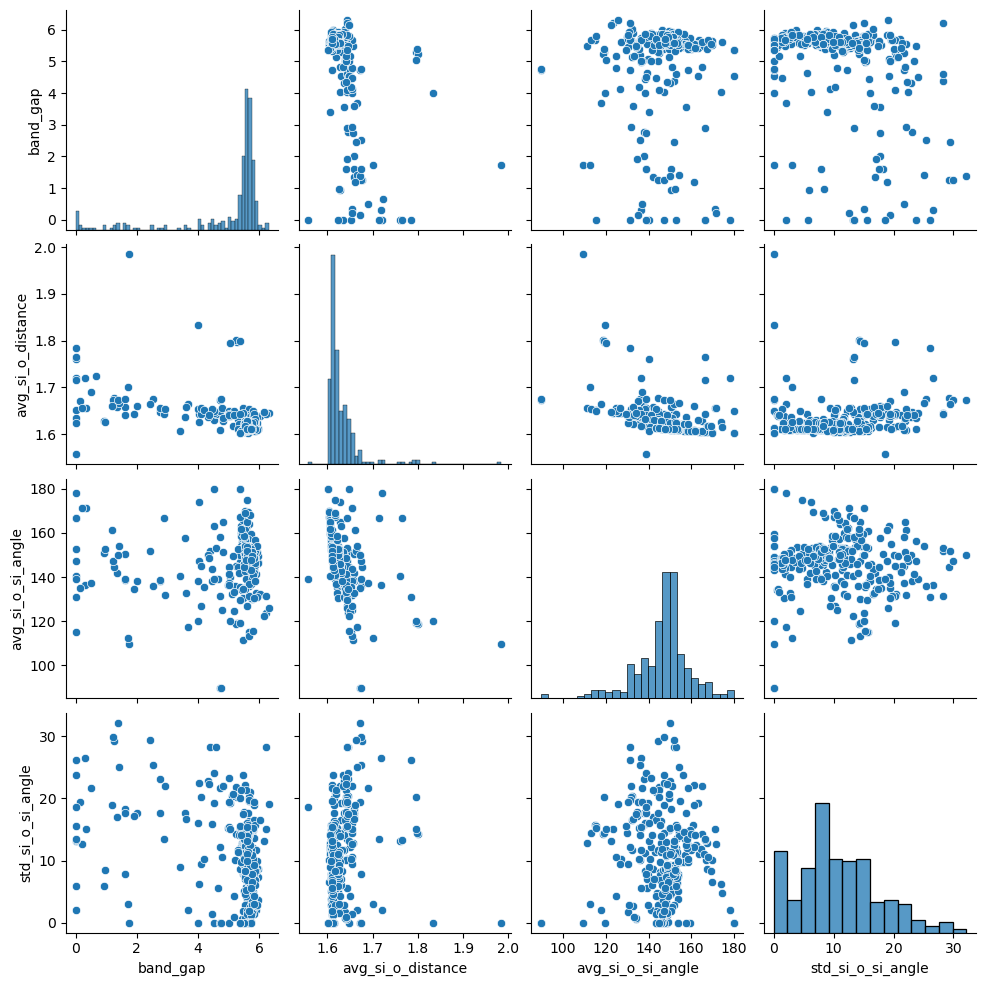

In [28]:
sns.pairplot(
    df_structures[
        [
            "band_gap",
            "avg_si_o_distance",
            "avg_si_o_si_angle",
            "std_si_o_si_angle"
        ]
    ]
)

plt.show()

In [29]:
from sklearn.metrics import r2_score, mean_absolute_error

pred = model.predict(X_test)

print("R2:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))

R2: 0.43639401619392193
MAE: 0.46760099230769187


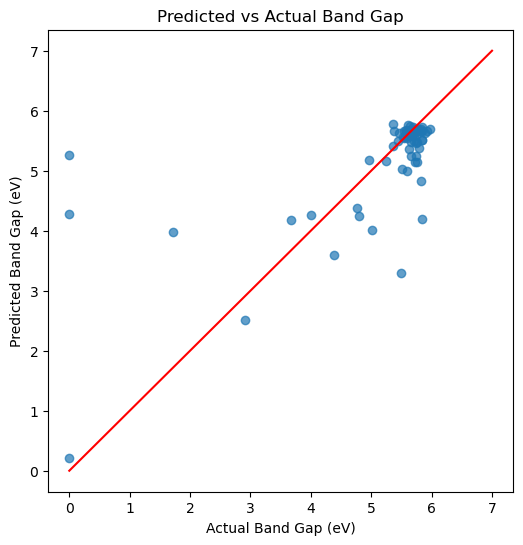

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, pred, alpha=0.7)

plt.plot([0,7], [0,7], color="red")

plt.xlabel("Actual Band Gap (eV)")
plt.ylabel("Predicted Band Gap (eV)")
plt.title("Predicted vs Actual Band Gap")

plt.show()

In [31]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [32]:
import shap

In [33]:
import shap
print(shap.__version__)

0.51.0


In [34]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

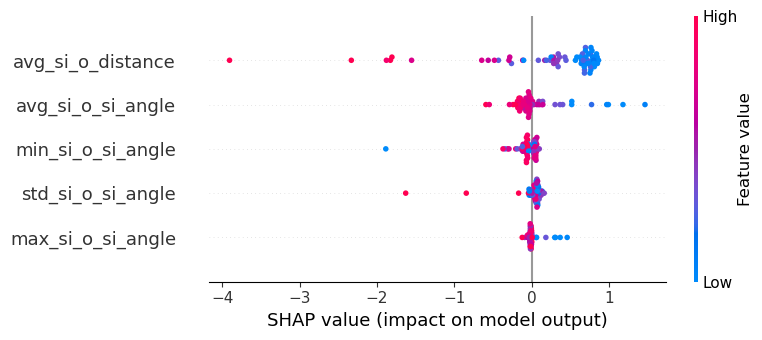

In [35]:
shap.summary_plot(shap_values, X_test)

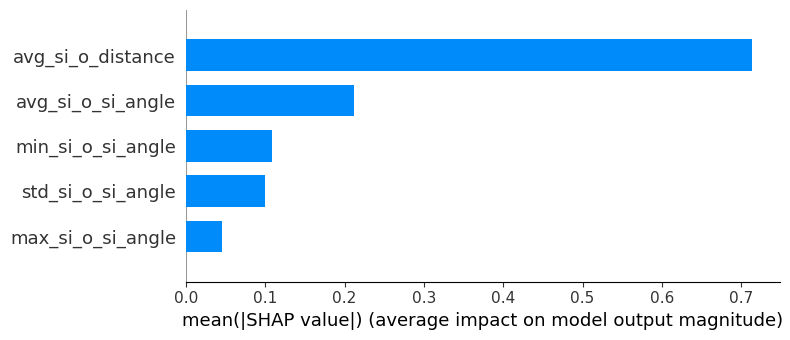

In [36]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [38]:
print(model)

RandomForestRegressor(n_estimators=200, random_state=42)


In [42]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

print("Saving model...")
joblib.dump(model, "../models/SiO2_model.pkl")
print("Model saved successfully!")

Saving model...
Model saved successfully!


In [47]:
# =========================
# MINI PIPELINE TEST
# =========================

import joblib
import pandas as pd

print("Loading model...")

model = joblib.load("../models/SiO2_model.pkl")

print(" Model loaded successfully!")


composition = input("Enter material: ")

sample_input = pd.DataFrame(
    [[1.6, 145, 120, 170, 15]],
    columns=[
    "avg_si_o_distance",
    "avg_si_o_si_angle",
    "min_si_o_si_angle",
    "max_si_o_si_angle",
    "std_si_o_si_angle"
]
)

prediction = model.predict(sample_input)
band_gap = prediction[0]


is_metallic = (band_gap == 0)


def recommend_application(bg):
    if bg == 0:
        return ["Conductors", "Electrodes"]
    elif bg < 3:
        return ["Semiconductors", "Solar cells"]
    else:
        return ["Insulators", "Coatings"]

applications = recommend_application(band_gap)


print("\n==============================")
print(" Material Analysis Result")
print("==============================")

print("Material:", composition)
print("Band Gap:", band_gap)
print("Type:", "Metal" if is_metallic else "Non-metal")
print("Applications:", applications)

print("==============================")

Loading model...
 Model loaded successfully!


Enter material:  SiO3



 Material Analysis Result
Material: SiO3
Band Gap: 4.490820500000008
Type: Non-metal
Applications: ['Insulators', 'Coatings']
